# US Equities Panel: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error in it
is silent where it is made and reaches every metric and every backtest after it. This notebook
settles which price is bought and which is sold and how far apart they are, checks that every
labelled row really has both, measures how much independent information the rows carry once
their windows overlap, measures what a signal the case study already believes in earns before
any feature is built, and writes the files stage 03 reads.

## Learning objectives

- Write a forward return as a formula that says which price opens the position, which price
  closes it, and how many trading sessions apart the two are
- Test, rather than assume, that every labelled row really has a price exactly that many
  sessions later, and give every row that has none a reason
- Apply a minimum-price and minimum-turnover screen after the return is computed, so that
  dropping one row cannot change how far ahead another row looks
- Measure how much of its forward window one row shares with the next, and turn that into the
  number of independent observations a file of overlapping returns actually holds
- Measure what a signal the case study already believes in earns against the label, before any
  feature exists, using a standard error that allows for that sharing

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the split- and dividend-adjusted daily panel through
`load_us_equities()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the label set, the horizons and the holdout boundary.
Writes `labels/fwd_ret_1d.parquet`, `labels/fwd_ret_5d.parquet` and
`labels/fwd_ret_21d.parquet`, each next to a small JSON file recording a hash of what is in
it. `03_financial_features.py` reads `fwd_ret_1d.parquet`, which it names directly; the model
stages read the variants through `labels.variants`.

In [1]:
"""US Equities Panel: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.diagnostic.splitters.calendar import TradingCalendar

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_us_equities
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "us_equities_panel"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

`START_DATE` is where the price history begins, and moving it forward costs more than the
sessions it removes. The tradability screen in Section B needs a month of trailing volume
before it admits any stock, so the first sessions after a later start carry none at all, and
both the dispersion in Section E and the rank correlation in Section G need a wide
cross-section of stocks on each session before they mean anything.

In [2]:
START_DATE = "1990-01-01"

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and read from there, so
that the notebook and the model stages downstream cannot end up holding two copies of the
same horizon.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and
both are declared in trading sessions.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Dd"))
    for name in LABEL_NAMES
}
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
END_DATE = setup["evaluation"]["holdout_end"]

# The tradability screen, Section B. `03_financial_features` carries the same three constants
# and rebuilds the screen from them.
MIN_PRICE, MIN_ADV_USD, ADV_WINDOW = 5.0, 1_000_000, 21

for name in LABEL_NAMES:
    role = "the primary label" if name == PRIMARY_LABEL else "a variant"
    plural = "s" if HORIZONS[name] > 1 else ""
    print(
        f"{name} is {role}: the return over the next {HORIZONS[name]} trading session{plural}, "
        "so a model trained on it predicts a move that far out and a strategy using it holds a "
        "position that long."
    )
print(
    f"Prices run from {START_DATE} to {END_DATE}, and every diagnostic below stops at "
    f"{HOLDOUT_START}. A return that has not finished by then belongs to the holdout, which is "
    "written into the label files and read by nothing until the case study is finished."
)
print(
    f"A stock is tradable on a session when its printed close is over ${MIN_PRICE:.0f} and its "
    f"dollar volume over the {ADV_WINDOW} sessions ending on it - all of which it has to have "
    f"traded - averaged more than ${MIN_ADV_USD:,}, which is roughly what a decile-sized "
    "position needs in order to be filled without moving the price."
)

fwd_ret_1d is the primary label: the return over the next 1 trading session, so a model trained on it predicts a move that far out and a strategy using it holds a position that long.
fwd_ret_5d is a variant: the return over the next 5 trading sessions, so a model trained on it predicts a move that far out and a strategy using it holds a position that long.
fwd_ret_21d is a variant: the return over the next 21 trading sessions, so a model trained on it predicts a move that far out and a strategy using it holds a position that long.
Prices run from 1990-01-01 to 2018-03-31, and every diagnostic below stops at 2016-01-01. A return that has not finished by then belongs to the holdout, which is written into the label files and read by nothing until the case study is finished.
A stock is tradable on a session when its printed close is over $5 and its dollar volume over the 21 sessions ending on it - all of which it has to have traded - averaged more than $1,000,000, which is roughly what a d

## A. The learning task

The hypothesis is cross-sectional and it is about breadth. No single US stock carries much
predictable return, but the panel is wide, and the Fundamental Law of Active Management says
a weak per-stock edge applied across thousands of names can still add up to a portfolio-level
one. The claim to test is that stocks can be ranked against each other on the strength of
their recent price history, so the label is a forward price return and the strategy that
consumes it is long-short across the deciles of that ranking.

The decision cadence comes from `setup.yaml`: the position is decided at a daily close and
entered at the next open. That fixes the primary horizon at one session, which is also the
horizon with the least overlap and therefore the most independent rows. The weekly and
monthly variants ask whether the same ranking still pays when the book turns over a fifth
and a twentieth as often - a question about cost and turnover rather than a second
hypothesis.

## B. Preparation before the label

A forward window is meaningful only on a price series that is adjusted, ordered and complete.
`adj_close` carries the split and dividend adjustment, so a return taken across a split does
not register the split as a price move; sorting by `symbol` then `timestamp` is what makes a
shift mean "the next session for this stock".

The tradability screen asks a different question and therefore reads a different price. A stock
enters on a date only if its **printed close** is above five dollars and the dollar volume it
actually traded averaged more than a million a day over the previous month: `close` for the
price leg, and `close * volume` averaged over 21 sessions for the liquidity leg. Both figures
are ones the tape carried on the day, so both are knowable when the position is decided.

The liquidity leg is counted in sessions, exactly as the forward window in Section C is. The
average runs over the stock's own rows - a session it sat out contributed no volume and is not
part of what it turned over - but the row qualifies only where those 21 rows are the 21
consecutive sessions ending on it. Without that condition a stock returning from a month-long
halt qualifies on the volume it traded before the halt, which is not what it turns over now.
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) screens the same panel under the
same condition, and [`03_financial_features`](03_financial_features.ipynb) rebuilds it from
the same three constants, so all three stages admit the same stock-sessions.

The adjusted series cannot answer that question, because its adjustment is anchored at the end
of the vendor file rather than at the row. `adj_close` on an early date is that date's price
divided by every split and dividend between it and the file's last session, so `close /
adj_close` equals one on each stock's final session and grows going backwards. A five dollar
floor on it screens on corporate actions that had not happened yet rather than on the share
price, and it drops stock-dates that printed well above five dollars on the day. What it drops
is concentrated in the early sample, which is where the earliest folds train.

Dollar volume needs no adjustment at all, because a two-for-one split halves the price and
doubles the shares and leaves `close * volume` unchanged through it. `adj_close * adj_volume`
does not survive the same test: `adj_volume` carries only the split factor while `adj_close`
carries splits and dividends, so their product keeps the end-anchored dividend factor and
understates what a dividend payer traded, by more the further back the date.

**The screen runs after the forward return is computed, not before.** Once ineligible rows are
dropped, the row that sits one place ahead of a kept row is no longer the next session: a stock
that falls below either threshold and recovers would carry a label spanning the whole excursion,
reported as a one-session return. Running the screen afterwards reaches the same eligible
universe, because it removes whole rows and never changes what any row it keeps is looking
forward at. Section D applies it, once every window has been checked.

In [4]:
prices = load_us_equities(start_date=START_DATE, end_date=END_DATE)
if prices.schema["timestamp"] == pl.Datetime:
    prices = prices.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))
prices = prices.sort(["symbol", "timestamp"])

# Recorded as every label's `inputs`: a re-run against a refreshed download is otherwise
# indistinguishable from this one. `adj_close` sets the label values while the printed close and
# volume decide which rows are written, so a corrected volume moves the artifact on its own.
MARKET_DATA_DIGEST = value_digest(prices, ["symbol", "timestamp", "close", "volume", "adj_close"])

print(f"{prices['symbol'].n_unique():,} stocks, {prices.height:,} rows")
print(f"Dates {prices['timestamp'].min()} to {prices['timestamp'].max()}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

3,199 stocks, 14,498,930 rows
Dates 1990-01-02 to 2018-03-27
market_data digest: 81db7d7920165013


One thing has to be settled before any horizon can be counted: which of the dates in the
archive are trading sessions. A trading session is a date the exchange held a market, and the
archive carries a small number of stray prints on dates it did not - a date that was never
open is not a date a position can be entered or closed on. `evaluation.calendar` in
`config/setup.yaml` names the exchange, and `get_sessions` maps each date to the session that
settles it, so a date that maps to itself is one the exchange held and a stray print maps to a
neighbour instead. [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) makes the same
check on the same archive.

Numbering the surviving dates in order gives each one a position, and the difference between
two positions is the number of sessions between them. That counter is what makes "five
sessions ahead" mean five sessions rather than five rows, and the stray-print rows are dropped
with the join, so nothing off-session reaches a label file. The files this notebook writes
therefore carry only session dates, which is what lets
[`utils/cv_splits.py`](../../utils/cv_splits.py) count a purge gap by position in a label
file's own timeline and get sessions.

In [5]:
dates = prices.select("timestamp").unique().sort("timestamp")
settling_session = pl.Series(
    TradingCalendar(setup["evaluation"]["calendar"])
    .get_sessions(pd.DatetimeIndex(dates["timestamp"].to_list(), tz="UTC"))
    .to_numpy()
).cast(pl.Date)
sessions = (
    dates.filter(settling_session == pl.col("timestamp"))
    .with_row_index("session")
    .with_columns(pl.col("session").cast(pl.Int64))
)

panel = prices.join(sessions, on="timestamp", how="inner").sort(["symbol", "timestamp"])

print(
    f"{sessions.height:,} of {dates.height:,} dates in the archive are "
    f"{setup['evaluation']['calendar']} sessions; the other {dates.height - sessions.height} "
    f"carry stray prints and take {prices.height - panel.height:,} rows with them"
)

7,114 of 7,234 dates in the archive are NYSE sessions; the other 120 carry stray prints and take 165 rows with them


What the panel holds, a decade at a time, and two things in it that shape the rest of the
notebook. The number of stocks quoting on a session grows steadily across the sample, so a
threshold written as a fixed number of names would mean something different at the start than
at the end - Section G states its minimum cross-section as a share of the median instead. And
the median stock's daily turnover grows far faster than its price does, so the dollar-volume
leg of the tradability screen bites hardest on the early years and barely at all on the late
ones. Read the last two columns against each other: the price column is flat and the turnover
column is not.

In [6]:
panel.with_columns((pl.col("timestamp").dt.year() // 10 * 10).alias("decade")).group_by(
    "decade"
).agg(
    pl.col("timestamp").n_unique().alias("sessions"),
    pl.col("symbol").n_unique().alias("stocks"),
    (pl.len() / pl.col("timestamp").n_unique()).round(0).alias("stocks_per_session"),
    pl.col("close").median().round(2).alias("median_close"),
    (pl.col("close") * pl.col("volume")).median().round(0).alias("median_dollar_volume"),
).sort("decade")

decade,sessions,stocks,stocks_per_session,median_close,median_dollar_volume
i32,u32,u32,f64,f64,f64
1990,2528,1803,1248.0,23.0,849507.0
2000,2515,2596,2187.0,21.6,4.26921e6
2010,2071,3199,2821.0,24.33,8.279562e6


## C. Label construction

One execution convention, written once and applied at all three horizons:

$$r^{(h)}_{i,t} = \frac{P_{i,t+h}}{P_{i,t}} - 1$$

where $P$ is the adjusted close of stock $i$ and $t+h$ is $h$ **trading sessions** later:
Chapter 7.2's close-to-close convention. It is not the convention the backtest fills at -
`setup.yaml` places execution at the next open - and that difference is a real gap, left to
[`18_costs`](18_costs.ipynb), which sweeps commission and spread rather than the return
definition.

Stepping $h$ rows forward inside one stock is **not** the same as stepping $h$ sessions
forward. A stock that was halted, or that the vendor simply has no quote for, is missing those
dates from its own rows, so its $h$-th next row lands further ahead than $h$ sessions and the
label reports a longer price change under a shorter name. It is a rare event on this panel and
that is what makes it dangerous: too rare to meet in a spot check, common enough to put
thousands of mislabelled rows into a file nothing downstream can tell apart from the rest.

So the closing price is not read off the $h$-th next row at all. It is looked up at the session
numbered $h$ higher, which is what `rows_sessions_ahead` builds: the stock's own row on that
session, re-keyed to the session the window opens on, so that a plain join attaches each row to
the price that closes it. Where the stock has no observation on that exact session there is
nothing to divide by and the label is null rather than approximate. Sessions in between do not
enter the formula and are not required.

`from_end` counts sessions back from each stock's last one, for Section D's boundary profile.
Neither it nor `session` reaches a label file, which writes three columns.

In [7]:
def rows_sessions_ahead(horizon: int) -> pl.DataFrame:
    """Each stock's row `horizon` sessions later, re-keyed to the session the window opens on."""
    return panel.select(
        "symbol",
        (pl.col("session") - horizon).alias("session"),
        pl.col("session").alias("_end_session"),
        pl.col("timestamp").alias("_label_end"),
        pl.col("adj_close").alias("_end_close"),
    )


labels_df = panel.with_columns(
    (pl.col("session").max().over("symbol") - pl.col("session")).alias("from_end")
)
for label_name, horizon in HORIZONS.items():
    labels_df = (
        labels_df.join(
            rows_sessions_ahead(horizon).select("symbol", "session", "_end_close"),
            on=["symbol", "session"],
            how="left",
        )
        .with_columns((pl.col("_end_close") / pl.col("adj_close") - 1).alias(label_name))
        .drop("_end_close")
    )

print(f"Constructed {', '.join(LABEL_NAMES)} on {panel.height:,} stock-sessions")

Constructed fwd_ret_1d, fwd_ret_5d, fwd_ret_21d on 14,498,765 stock-sessions


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity the
label claims. Each property below fails silently and leaves plausible numbers behind, so each
is asserted rather than described.

The third assertion is a full reconciliation rather than a bound. Every row carrying no label
is attributed to exactly one cause - the window reaches past the last session the stock has, the
stock has no observation on the session that closes it, or a price is absent at one end - and
the four counts have to sum to the height of the frame. A label crossing a symbol boundary, or a
short label masked by a longer one's null set, would break that identity, and on this panel the
second is the likelier failure: the monthly label is null on twenty more rows per stock than the
daily one, and a single shared `drop_nulls` would silently trim the daily file to the monthly
one's support.

In [8]:
for label_name, horizon in HORIZONS.items():
    checked = labels_df.join(rows_sessions_ahead(horizon), on=["symbol", "session"], how="left")
    tail = pl.col("from_end") < horizon
    absent = ~tail & pl.col("_end_session").is_null()
    unpriced = ~tail & ~absent & (pl.col("adj_close").is_null() | pl.col("_end_close").is_null())
    causes = {
        "past the stock's last session": tail,
        "the stock did not trade on the closing session": absent,
        "no price at an end": unpriced,
    }
    labelled = checked.drop_nulls(label_name)

    # 1. A window reaching past the stock's last session is null, never a value.
    assert checked.filter(tail)[label_name].null_count() == checked.filter(tail).height

    # 2. Every labelled window closes exactly `horizon` sessions after it opens.
    span = pl.col("_end_session") - pl.col("session")
    assert labelled.filter(span != horizon).height == 0, label_name

    # 3. Labelled rows plus the three causes account for every row, each cause once.
    counts = {cause: checked.filter(cond).height for cause, cond in causes.items()}
    assert labelled.height + sum(counts.values()) == checked.height, (label_name, counts)

    # 4. No discrete label is derived from a null return - vacuous by dtype here, since
    #    this notebook writes continuous labels only.
    assert labels_df.schema[label_name] == pl.Float64, label_name

    unlabelled = ", ".join(f"{n:,} {cause}" for cause, n in counts.items())
    print(
        f"{label_name}: {labelled.height:,} labelled, every one closing exactly {horizon} "
        f"session(s) later; unlabelled {unlabelled}"
    )

fwd_ret_1d: 14,494,141 labelled, every one closing exactly 1 session(s) later; unlabelled 3,199 past the stock's last session, 1,425 the stock did not trade on the closing session, 0 no price at an end


fwd_ret_5d: 14,481,265 labelled, every one closing exactly 5 session(s) later; unlabelled 15,978 past the stock's last session, 1,522 the stock did not trade on the closing session, 0 no price at an end


fwd_ret_21d: 14,429,407 labelled, every one closing exactly 21 session(s) later; unlabelled 66,478 past the stock's last session, 2,880 the stock did not trade on the closing session, 0 no price at an end


Position zero below is each stock's last session. The non-null rate has to fall to zero over
exactly the last `horizon` positions and be flat beyond them. A scalar count of valid rows shows
neither failure this catches: a tail fabricated instead of nulled, or a short label masked by a
longer one's null set. The flat stretch is at one for practical purposes - the rows beyond the
horizon that are still null are the missed closing sessions the reconciliation above counted,
and they are too rare to see at this scale. The figure reads only which rows are null and never
a label value, so the holdout does not affect it, and it is drawn before the tradability screen
because the screen removes whole rows rather than nulling them.

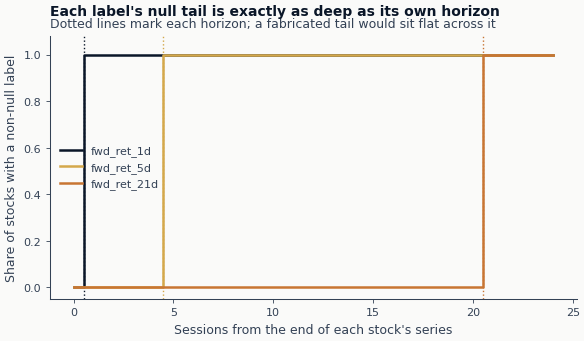

In [9]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"], COLORS["copper"])):
    ax.step(profile["from_end"], profile[name], where="mid", color=colour, lw=1.8, label=name)
    ax.axvline(HORIZONS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Sessions from the end of each stock's series")
ax.set_ylabel("Share of stocks with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Each label's null tail is exactly as deep as its own horizon",
    subtitle="Dotted lines mark each horizon; a fabricated tail would sit flat across it",
)
ax.legend(loc="center left", frameon=False)
show_with_alt(fig, "Non-null label rate by position from the end of each stock's series.")

The tradability screen declared in Section B is applied here, on the frame whose windows the
assertions above have just checked. `session` came from the market's own list of dates and does
not renumber, so the stretches the screen removes stay visible as gaps to Section F rather than
closing up; that is the grid the overlap statistics have to be counted on.

In [10]:
ADV_COVERED = pl.col("session") - pl.col("session").shift(ADV_WINDOW - 1) == ADV_WINDOW - 1

# Sorted first: the label joins above carry no ordering guarantee, and both the rolling
# average and the coverage test below read neighbouring rows.
screened = labels_df.sort(["symbol", "timestamp"]).with_columns(
    (pl.col("close") * pl.col("volume")).rolling_mean(ADV_WINDOW).over("symbol").alias("adv_21d"),
    ADV_COVERED.over("symbol").alias("adv_covered"),
)
eligible = screened.filter(
    pl.col("adv_covered") & (pl.col("close") > MIN_PRICE) & (pl.col("adv_21d") > MIN_ADV_USD)
)

print(
    f"Eligible: {eligible.height:,} of {labels_df.height:,} symbol-sessions "
    f"({eligible.height / labels_df.height:.1%}), {eligible['symbol'].n_unique():,} stocks"
)
print(
    f"  {screened.filter(~pl.col('adv_covered').fill_null(False)).height:,} rows carry no "
    f"unbroken {ADV_WINDOW}-session volume window and cannot be screened on turnover at all"
)

Eligible: 9,978,112 of 14,498,765 symbol-sessions (68.8%), 3,178 stocks


  75,966 rows carry no unbroken 21-session volume window and cannot be screened on turnover at all


## E. Distribution and base rate

What scale is the label, and does it mean the same thing across stocks and across regimes?
Everything from here through Section G is computed on rows whose forward window **closes**
before the holdout opens, not on rows merely observed before it. A row observed a few days
before the boundary has its outcome decided by prices inside the holdout, so filtering on the
observation date leaves holdout prices in the diagnostic while appearing not to. The label
files themselves keep every tradable row, holdout included: what is restricted here is what
this notebook is allowed to look at, not what it writes.

In [11]:
dev = {}
for label_name, horizon in HORIZONS.items():
    # The date a label resolves on is a property of the label, so it comes from the complete
    # series the label was built on. Looking it up on the screened frame instead would return the
    # next tradable date, which is later and depends on what happens after the decision.
    ends = rows_sessions_ahead(horizon).select("symbol", "session", "_label_end")
    dev[label_name] = (
        eligible.join(ends, on=["symbol", "session"], how="left")
        .filter(pl.col("_label_end") < HOLDOUT_START)
        .drop_nulls(label_name)
    )
    frame = dev[label_name]
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_1d: 8,764,331 development rows through 2015-12-30


fwd_ret_5d: 8,754,174 development rows through 2015-12-23


fwd_ret_21d: 8,713,856 development rows through 2015-12-01


All three labels go on one axis with identical bins and a logarithmic count axis. The claim
the figure has to support is about shape rather than width - three dispersion scalars would
carry the width, and they are printed below - and the shape here is that the longer horizons
move mass out of the centre into both tails rather than spreading the body evenly. The axis
is symmetric and narrower than any label's range, so rows outside it are counted below rather
than drawn.

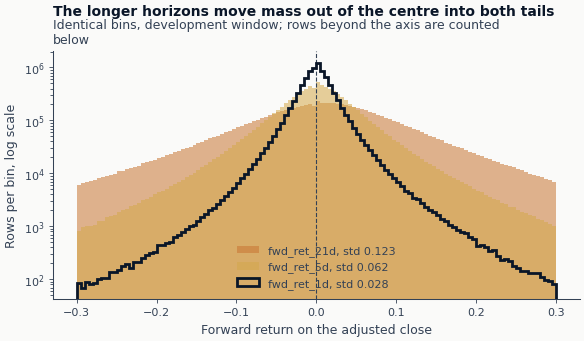

fwd_ret_1d: std 0.02849, 1.00x the primary label against 1.00 under square-root-of-horizon scaling, kurtosis 96.5, 1,182 left and 1,265 right of the axis
fwd_ret_5d: std 0.06187, 2.17x the primary label against 2.24 under square-root-of-horizon scaling, kurtosis 39.8, 12,394 left and 17,268 right of the axis
fwd_ret_21d: std 0.12338, 4.33x the primary label against 4.58 under square-root-of-horizon scaling, kurtosis 21.6, 112,951 left and 149,551 right of the axis


In [12]:
bins = np.linspace(-0.30, 0.30, 121)
styles = [
    dict(color=COLORS["copper"], alpha=0.55, zorder=1),
    dict(color=COLORS["amber"], alpha=0.55, zorder=2),
    dict(color=COLORS["blue"], histtype="step", lw=2, zorder=3),
]
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, style in zip(reversed(LABEL_NAMES), styles):
    series = dev[name][name]
    ax.hist(series.to_numpy(), bins=bins, label=f"{name}, std {series.std():.3f}", **style)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward return on the adjusted close")
ax.set_ylabel("Rows per bin, log scale")
add_message_title(
    ax,
    "The longer horizons move mass out of the centre into both tails",
    subtitle="Identical bins, development window; rows beyond the axis are counted below",
)
ax.legend(loc="lower center", frameon=False)
show_with_alt(fig, "Histograms of all three labels on identical bins and a log count axis.")

std = {name: dev[name][name].std() for name in LABEL_NAMES}
for name in LABEL_NAMES:
    frame, column = dev[name], pl.col(name)
    out = frame.filter(column < bins[0]).height, frame.filter(column > bins[-1]).height
    root_h = math.sqrt(HORIZONS[name] / PRIMARY_HORIZON)
    print(
        f"{name}: std {std[name]:.5f}, {std[name] / std[PRIMARY_LABEL]:.2f}x the primary label "
        f"against {root_h:.2f} under square-root-of-horizon scaling, kurtosis "
        f"{frame[name].kurtosis():.1f}, {out[0]:,} left and {out[1]:,} right of the axis"
    )

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label ranked
across a cross-section, the quantity that has to be stable is the spread the model ranks
within: where it is not, the same rank correlation buys a different amount of return. The
spread is measured across stocks on one session and only then averaged over the year, so what
the chart reports is how far apart two stocks are on a given day - which is what a ranking
model is scored on - and not how far the whole panel moved between one day and the next.

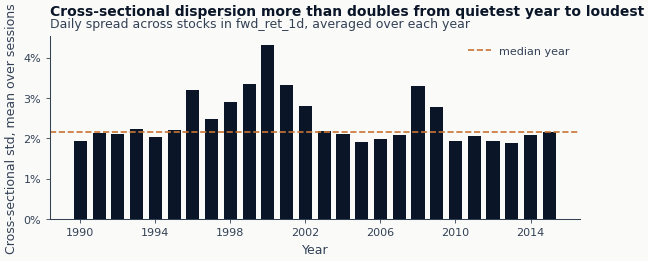

dispersion peaks at 4.31% in 2000 against 1.88% in 2013, a ratio of 2.29; median year 2.15%


In [13]:
annual = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"))
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean())
    .sort("year")
)
peak, low = (annual.sort("dispersion", descending=d).row(0, named=True) for d in (True, False))
median_dispersion = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_dispersion, color=COLORS["copper"], linestyle="--", lw=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::4])
ax.set_xlabel("Year")
ax.set_ylabel("Cross-sectional std, mean over sessions")
format_pct_axis(ax)
add_message_title(
    ax,
    "Cross-sectional dispersion more than doubles from quietest year to loudest",
    subtitle=f"Daily spread across stocks in {PRIMARY_LABEL}, averaged over each year",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Annual mean of the daily cross-sectional dispersion of the primary label.")

print(
    f"dispersion peaks at {peak['dispersion']:.2%} in {peak['year']:.0f} against "
    f"{low['dispersion']:.2%} in {low['year']:.0f}, a ratio of "
    f"{peak['dispersion'] / low['dispersion']:.2f}; median year {median_dispersion:.2%}"
)

On the development window the daily label has a standard deviation of 0.02849, the weekly
0.06187 and the monthly 0.12338 - 2.17x and 4.33x the daily one, against the 2.24x and 4.58x
square-root-of-horizon scaling implies, so the longer horizons come out slightly narrower than
a run of independent daily moves would make them. Their tails thin as the horizon lengthens:
excess kurtosis falls from 96.5 on the daily label to 21.6 on the monthly one, because a month
of returns averages away the single-session jumps that dominate the daily tail. The spread a
ranking model works inside is not stable through time: cross-sectional dispersion peaks at
4.31% in 2000 against 1.88% in 2013, a ratio of 2.29, with a median year of 2.15%.

## F. Overlap and effective sample size

Sampling a multi-session label at every session makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and what the rows are worth once it is priced
in. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting per stock,
because concurrency is a property of one stock's own overlapping windows.

Both are counted on `session`, the market's list of dates, rather than on position among the
rows that survive into the frame being measured. Counting positions among survivors would make
the two rows either side of a removed stretch adjacent, pairing windows that share nothing and
reporting more overlap than there is.

The daily label is the case that fixes the arithmetic: consecutive one-session forward returns
are built from disjoint returns, so its effective count has to come back equal to its row
count exactly. A window that counted its anchor bar as consumed would halve it instead.

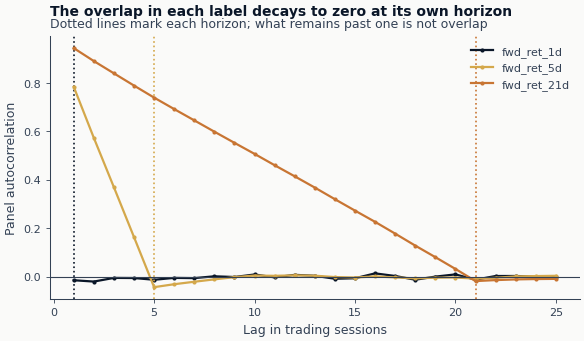

fwd_ret_1d: N=8,764,331, N_eff=8,764,331, ratio 1.0000 against 1.0000 for windows overlapping this fully; autocorrelation -0.015 at lag 1


fwd_ret_5d: N=8,754,174, N_eff=1,776,784, ratio 0.2030 against 0.2000 for windows overlapping this fully; autocorrelation 0.784 at lag 1 and -0.044 at lag 5


fwd_ret_21d: N=8,713,856, N_eff=436,516, ratio 0.0501 against 0.0476 for windows overlapping this fully; autocorrelation 0.944 at lag 1 and -0.019 at lag 21


In [14]:
max_lag = max(HORIZONS.values()) + 4
acf = {
    name: panel_autocorrelation(dev[name], name, max_lag=max_lag, bar_col="session")
    for name in LABEL_NAMES
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, max_lag + 1)
for name, colour in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"], COLORS["copper"])):
    ax.plot(lags, acf[name], "o-", ms=3, c=colour, lw=1.6, label=name)
    ax.axvline(HORIZONS[name], color=colour, linestyle=":", lw=1.2)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in trading sessions")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "The overlap in each label decays to zero at its own horizon",
    subtitle="Dotted lines mark each horizon; what remains past one is not overlap",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of all three labels against lag in trading sessions.")

# A horizon-h label consumes the h returns realised over its window, and its neighbour one
# session later shares h-1 of them, so average uniqueness converges to 1/h.
for label_name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(dev[label_name], horizon=horizon, bar_col="session")
    at_horizon = "" if horizon == 1 else f" and {acf[label_name][horizon - 1]:.3f} at lag {horizon}"
    print(
        f"{label_name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / horizon:.4f} for windows overlapping this fully; autocorrelation "
        f"{acf[label_name][0]:.3f} at lag 1{at_horizon}"
    )

The daily label's 8,764,331 development rows carry 8,764,331 effective observations, a ratio of
exactly 1.0000, as windows that share nothing require. The weekly label's 8,754,174 rows carry
1,776,784, a ratio of 0.2030 against the 0.2000 a fully overlapped five-session window implies,
and the monthly label's 8,713,856 rows carry 436,516, a ratio of 0.0501 against 0.0476. Both
variants sit above their reference value because a stock dropping out of the tradable universe
ends an overlap early. Autocorrelation at lag 1 is -0.015 for the daily label, 0.784 for the
weekly and 0.944 for the monthly, and the two variants fall to -0.044 at lag 5 and -0.019 at
lag 21. So the monthly label buys twenty times the rows of a monthly sample and roughly one
twentieth of the evidence per row. The purge gap a fold needs is set by the forward window
itself, not by these counts.

## G. Baseline floor

One signal against the primary label, on the same rows the rest of the notebook is restricted
to, with no feature engineering: the skip-month momentum the case study's hypothesis names, the
return from twelve months back to one month back, which `setup.yaml` declares as the causal
treatment and `03_financial_features` recomputes under the name `ret_12m_skip`. Jegadeesh and
Titman (1993) skip the most recent month because short-horizon reversal runs against momentum
inside it. Measuring what this earns before building any feature is what makes a later
improvement mean something.

The information coefficient is the rank correlation between the signal and the label across the
stocks quoting on one session, averaged over sessions. That is the quantity a ranking model is
scored on: it asks whether the stocks the signal put at the top outran the ones it put at the
bottom, on each day separately. Sessions with too thin a cross-section for a rank correlation
to mean anything are left out of the average, and the threshold is half the median
cross-section rather than a fixed count of stocks, so it carries over to a universe of another
size. The standard error is HAC-adjusted - widened to allow for the IC series being correlated
with itself from one session to the next, which an ordinary standard error assumes away.

The two lookbacks are looked up on the session list, exactly as the label's endpoint is, and
for the same reason: counting 252 rows back inside a stock that missed a session reaches
further back than twelve months.

In [15]:
MOMENTUM_LOOKBACK, MOMENTUM_SKIP = 252, 21  # 12-1 momentum, in trading sessions


def close_sessions_back(lag: int, name: str) -> pl.DataFrame:
    """Each stock's close `lag` sessions earlier, re-keyed to the session reading it."""
    return panel.select(
        "symbol", (pl.col("session") + lag).alias("session"), pl.col("adj_close").alias(name)
    )


# Built on the complete price series, for the reason the label is: a lookback taken on the
# screened frame reaches back past the sessions the screen removed.
momentum = (
    panel.select("symbol", "timestamp", "session")
    .join(close_sessions_back(MOMENTUM_SKIP, "_skip"), on=["symbol", "session"], how="left")
    .join(close_sessions_back(MOMENTUM_LOOKBACK, "_start"), on=["symbol", "session"], how="left")
    .select("symbol", "timestamp", (pl.col("_skip") / pl.col("_start") - 1).alias("ret_12m_skip"))
)
baseline = (
    dev[PRIMARY_LABEL]
    .join(momentum, on=["symbol", "timestamp"], how="left")
    .drop_nulls("ret_12m_skip")
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="ret_12m_skip",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Baseline: skip-month momentum against {PRIMARY_LABEL}, "
    f"{baseline.height:,} rows, minimum cross-section {min_obs:,} stocks"
)
print(
    f"  {ic.height:,} sessions carry both the signal and the label; {stats['n_periods']:,} of "
    f"them clear the minimum cross-section and are the ones averaged"
)
print(f"  mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: skip-month momentum against fwd_ret_1d, 8,388,007 rows, minimum cross-section 631 stocks
  6,300 sessions carry both the signal and the label; 5,062 of them clear the minimum cross-section and are the ones averaged
  mean IC 0.0105
  HAC t 4.76 on 9 Bartlett lags, naive t 5.35, p 2e-06


Skip-month momentum earns a mean information coefficient of 0.0105 against the daily label,
positive as the momentum hypothesis implies. It is averaged over the 5,062 sessions that carry
at least 631 stocks with both a signal and a label, out of the 6,300 sessions that carry any;
the 1,238 left out are early ones whose cross-section is too thin for a rank correlation to say
much. Under the ordinary standard error that is a t-statistic of 5.35; the Newey-West rule picks
9 lags here, well above the zero a one-session horizon needs on its own, and the HAC statistic
is 4.76 with a p-value of 2e-06. So a feature has to beat a mean IC of 0.0105 that the
correction still separates from zero, and that correction costs about a tenth of the statistic
even where the label itself does not overlap - the IC series carries persistence of its own,
which is what the lag rule is reading.

## H. Artifacts and the audit record

Every label file gets a small JSON file written beside it, `labels/<name>.digest.json`. Its
job is to let a later stage decide whether the file it just read is the one it was built
against, without re-reading the data: the JSON holds a single hash of the label values, and any
change to any value or any row changes it. Beside the hash it records how many rows the file
has, which columns identify a row, the notebook that wrote it, and a hash of the price data the
label came from. That last one distinguishes a re-run against a refreshed download from a
re-run against the same one, which is otherwise invisible.

Each file is dropped to its own non-null rows, so the daily label keeps the rows the monthly
one cannot carry.

The folds that train models are derived per label by `case_studies/utils/cv_window.py` from
`config/setup.yaml` and the timeline of the label parquet written here, so which rows land in
these files is what sets where the fold boundaries fall.

In [16]:
for label_name in LABEL_NAMES:
    keys = ["timestamp", "symbol"]
    record = write_artifact(
        eligible.select([*keys, label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=keys,
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_1d.parquet: 9,975,281 rows, digest a6c40b6062b51db8


fwd_ret_5d.parquet: 9,964,883 rows, digest 37ddc3ab009cebc7


fwd_ret_21d.parquet: 9,923,398 rows, digest 7721a5d10d584fe0


The record Chapter 7.2 requires to close a label definition, one row per label, built from the
values computed above rather than written by hand.

In [17]:
readers = {PRIMARY_LABEL: "03_financial_features.py, as the label it names directly"}
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame = dev[label_name]
    print(
        f"\n{label_name}\n  anchor       split- and dividend-adjusted close at t"
        f"\n  horizon      {horizon} trading session{'s' if horizon > 1 else ''}, counted on the"
        " market's calendar and not on the stock's own rows"
        f"\n  resolution   fixed at t+h; daily closes need no intraday tie-break"
        f"\n  overlap      {horizon - 1} session{'s' if horizon != 2 else ''} shared by"
        " consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():+.5f}, std {frame[label_name].std():.5f}"
        f"\n  consumed by  {readers.get(label_name, 'the model stages, as a variant')}"
    )


Label audit record

fwd_ret_1d
  anchor       split- and dividend-adjusted close at t
  horizon      1 trading session, counted on the market's calendar and not on the stock's own rows
  resolution   fixed at t+h; daily closes need no intraday tie-break
  overlap      0 sessions shared by consecutive rows
  base rate    mean +0.00058, std 0.02849
  consumed by  03_financial_features.py, as the label it names directly

fwd_ret_5d
  anchor       split- and dividend-adjusted close at t
  horizon      5 trading sessions, counted on the market's calendar and not on the stock's own rows
  resolution   fixed at t+h; daily closes need no intraday tie-break
  overlap      4 sessions shared by consecutive rows
  base rate    mean +0.00278, std 0.06187
  consumed by  the model stages, as a variant

fwd_ret_21d
  anchor       split- and dividend-adjusted close at t
  horizon      21 trading sessions, counted on the market's calendar and not on the stock's own rows
  resolution   fixed at t+h; dai

## Key takeaways

1. **Count a horizon on the market's list of dates, not on a stock's own rows.** Stepping five
   rows forward inside a stock reaches five sessions ahead only if the stock has a quote on all
   of them; where it does not, the label reports a longer price change under a shorter name.
   Number the sessions once and look the closing price up on the session that closes the
   window, so a missing quote produces no label instead of the wrong one.
2. **Screen the universe after the label, not before it.** A tradability filter applied first
   makes the forward step count surviving rows, so the horizon stops being measured in trading
   sessions and the window silently spans whatever was removed. Applied afterwards it reaches
   the same universe, because it removes whole rows and never changes what a row it keeps is
   looking forward at.
3. **Give every unlabelled row a reason, and make the reasons add up.** A window running off
   the end of a stock's history, a stock that missed a session, and a label crossing from one
   stock into the next all fail without raising an error. A count of the labelled rows passes
   over all three; a reconciliation that has to sum to the height of the frame does not.
4. **Restrict a diagnostic by when the outcome is known, not by when it was observed.** A row
   observed before the holdout whose return finishes inside it is a holdout row, so the usable
   boundary is the boundary minus the horizon, counted in sessions.
5. **A row count overstates the evidence when forward windows overlap.** The effective count
   says by how much, and the one-session label is the case that proves the arithmetic: with
   windows that share nothing it has to come back unchanged.
6. **Measure what a known signal earns before building a feature.** A baseline the hypothesis
   already names, under a standard error that allows for the label's overlap, is what makes a
   later improvement a result rather than a number.

**Known limitations.** Close-to-close is not the next-open execution the backtest fills at, and
nothing here measures that gap. The window is checked at its two ends only, so a stock that was
untradable in the middle of a 21-session window still carries a label for it. The baseline is
one signal, on price history alone.

**Next**: [`03_financial_features`](03_financial_features.ipynb) builds the momentum,
volatility, liquidity and value features and screens the panel these labels are joined to.